# Distribution Feeder Synthesis — [Schweitzer et al. (2017)](https://ieeexplore.ieee.org/document/7895177)

Demonstrates the full Schweitzer algorithm for generating synthetic MV radial distribution feeders.

**Pipeline:** Parameters → Node generation → Tree connection → Node properties → Cable types → Cable lengths

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

from powergrid_synth import DistributionGrid, GridVisualizer
from powergrid_synth.distribution import (
    SchweetzerFeederGenerator,
    DistributionSynthParams,
    DistributionInputModel,
    compute_emergent_properties,
    validate_tree,
    compare_feeders,
    kl_divergence_discrete,
    fit_params_from_feeders,
)

## 1. Generate a Single Feeder with Default Parameters (Table III)

In [2]:
gen = SchweetzerFeederGenerator(seed=42)
G = DistributionGrid.from_nx(
    gen.generate_feeder(n_nodes=50, total_load_mw=8.0, total_gen_mw=1.0, v_nom_kv=10.0)
)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Root: {G.root}, Max hop: {G.max_hop}, Is radial: {G.is_radial}")
print(f"Nominal voltage: {G.graph['v_nom_kv']} kV")

Nodes: 50, Edges: 49
Root: 0, Max hop: 14, Is radial: True
Nominal voltage: 10.0 kV


## 2. Validate Tree Structure

In [3]:
issues = validate_tree(G)
if issues:
    print("Issues found:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("Valid radial tree (no issues)")
print(f"Total load: {G.total_load_mw:.2f} MW, Total gen: {G.total_gen_mw:.2f} MW")
print(f"Load nodes: {len(G.nodes_by_type('load'))}, Injection: {len(G.nodes_by_type('injection'))}, "
      f"Intermediate: {len(G.nodes_by_type('intermediate'))}")

Valid radial tree (no issues)
Total load: 13.52 MW, Total gen: 0.96 MW
Load nodes: 44, Injection: 1, Intermediate: 5


## 3. Emergent Properties

In [4]:
props = compute_emergent_properties(G)
for key, val in props.items():
    if isinstance(val, float):
        print(f"  {key:25s} = {val:.4f}")
    else:
        print(f"  {key:25s} = {val}")

  n_nodes                   = 50
  n_edges                   = 49
  max_hop                   = 14
  mean_degree               = 1.9600
  total_load_mw             = 13.5204
  total_gen_mw              = 0.9573
  frac_intermediate         = 0.1000
  frac_injection            = 0.0200
  mean_length_km            = 0.4659
  max_length_km             = 3.3962
  total_length_km           = 22.8270


## 4. Visualize Feeder Topology

Calculating layout 'hierarchical_tree'...


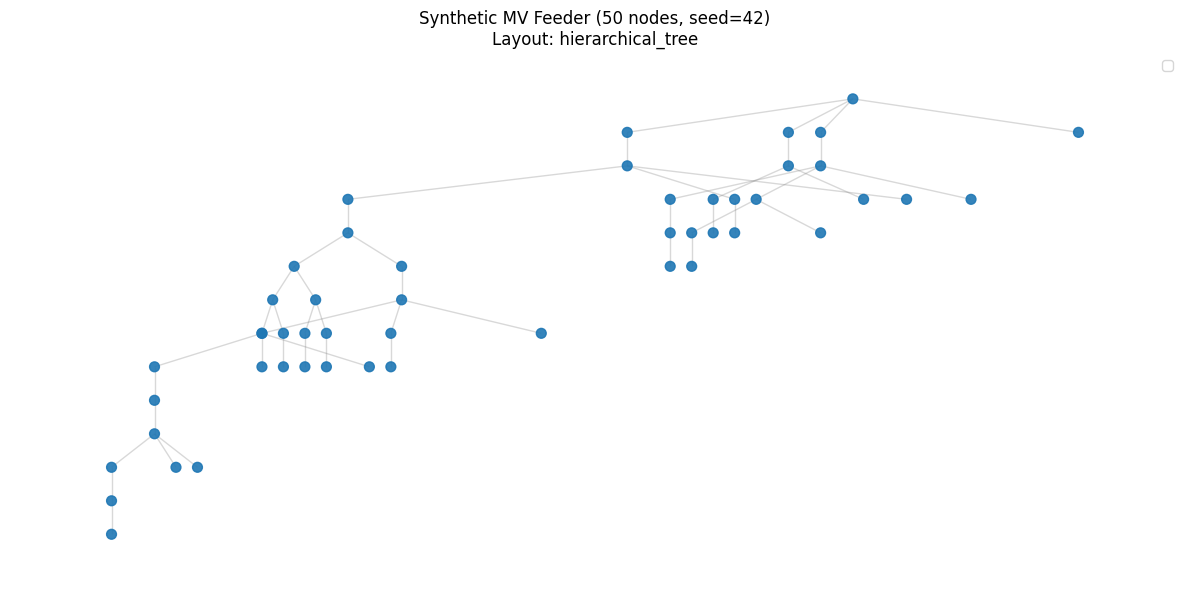

In [5]:
viz = GridVisualizer()
viz.plot_grid(
    G,
    layout="hierarchical_tree",
    title="Synthetic MV Feeder (50 nodes, seed=42)",
    figsize=(12, 6),
)

## 5. Statistical Distributions of the Generated Feeder

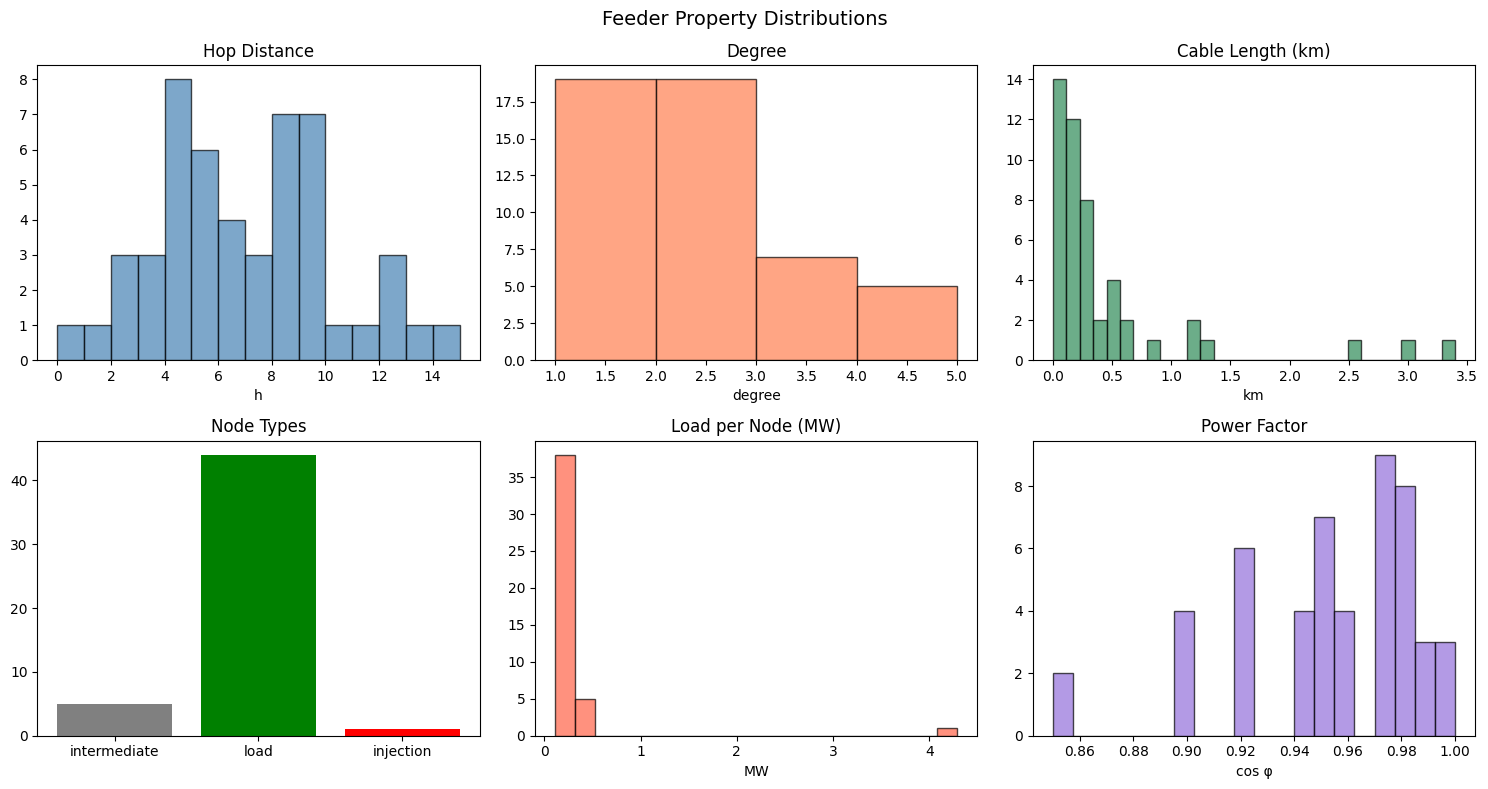

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Hop distance distribution
hops = [G.nodes[n]["h"] for n in G.nodes]
axes[0, 0].hist(hops, bins=range(max(hops) + 2), edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].set_title("Hop Distance")
axes[0, 0].set_xlabel("h")

# Degree distribution
degrees = [d for _, d in G.degree()]
axes[0, 1].hist(degrees, bins=range(1, max(degrees) + 2), edgecolor="black", alpha=0.7, color="coral")
axes[0, 1].set_title("Degree")
axes[0, 1].set_xlabel("degree")

# Cable length distribution
lengths = [G.edges[e]["length_km"] for e in G.edges]
axes[0, 2].hist(lengths, bins=30, edgecolor="black", alpha=0.7, color="seagreen")
axes[0, 2].set_title("Cable Length (km)")
axes[0, 2].set_xlabel("km")

# Node type breakdown
type_counts = Counter(G.nodes[n]["node_type"] for n in G.nodes)
axes[1, 0].bar(type_counts.keys(), type_counts.values(), color=["gray", "green", "red"])
axes[1, 0].set_title("Node Types")

# Load distribution
load_vals = [G.nodes[n]["P_mw"] for n in G.nodes if G.nodes[n].get("P_mw", 0) > 0]
axes[1, 1].hist(load_vals, bins=20, edgecolor="black", alpha=0.7, color="tomato")
axes[1, 1].set_title("Load per Node (MW)")
axes[1, 1].set_xlabel("MW")

# Power factor distribution
pf_vals = [G.nodes[n]["pf"] for n in G.nodes]
axes[1, 2].hist(pf_vals, bins=20, edgecolor="black", alpha=0.7, color="mediumpurple")
axes[1, 2].set_title("Power Factor")
axes[1, 2].set_xlabel("cos φ")

plt.suptitle("Feeder Property Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Generate an Ensemble and Compare

In [7]:
# Generate multiple feeders with different seeds
ensemble = []
for seed in range(10):
    g = SchweetzerFeederGenerator(seed=seed)
    feeder = DistributionGrid.from_nx(
        g.generate_feeder(n_nodes=50, total_load_mw=8.0, total_gen_mw=1.0)
    )
    ensemble.append(feeder)

print(f"Generated {len(ensemble)} feeders")
for i, f in enumerate(ensemble):
    print(f"  Feeder {i}: {f.number_of_nodes()} nodes, max_hop={f.max_hop}, "
          f"load={f.total_load_mw:.2f} MW, gen={f.total_gen_mw:.2f} MW, "
          f"radial={f.is_radial}")

Generated 10 feeders
  Feeder 0: 50 nodes, max_hop=15, load=9.91 MW, gen=0.92 MW, radial=True
  Feeder 1: 50 nodes, max_hop=13, load=7.72 MW, gen=1.01 MW, radial=True
  Feeder 2: 50 nodes, max_hop=14, load=8.58 MW, gen=0.99 MW, radial=True
  Feeder 3: 50 nodes, max_hop=14, load=7.66 MW, gen=1.04 MW, radial=True
  Feeder 4: 50 nodes, max_hop=13, load=7.83 MW, gen=0.96 MW, radial=True
  Feeder 5: 50 nodes, max_hop=15, load=9.58 MW, gen=1.08 MW, radial=True
  Feeder 6: 50 nodes, max_hop=13, load=8.71 MW, gen=0.92 MW, radial=True
  Feeder 7: 50 nodes, max_hop=15, load=9.94 MW, gen=1.06 MW, radial=True
  Feeder 8: 50 nodes, max_hop=14, load=8.85 MW, gen=0.97 MW, radial=True
  Feeder 9: 50 nodes, max_hop=12, load=8.13 MW, gen=0.95 MW, radial=True


## 7. KL-Divergence Comparison Between Two Feeders

In [8]:
# Compare the first two feeders of the ensemble
kl_results = compare_feeders(ensemble[0], ensemble[1])
print("KL-divergence between feeder 0 and feeder 1:")
for metric, val in kl_results.items():
    print(f"  {metric:25s} = {val:.4f}")

KL-divergence between feeder 0 and feeder 1:
  hop_distance_kl           = 1.9638
  degree_kl                 = 0.4858
  cable_length_kl           = 3.1603


## 8. 3D KDE Input Model

In [9]:
# Fit the input model from the ensemble
input_model = DistributionInputModel(seed=0)
input_model.fit(ensemble)

# Sample new input configurations
samples = input_model.sample(5)
print("Sampled input configurations (n_nodes, load_MW, gen_MW):")
for s in samples:
    print(f"  N={s.n_nodes}, Load={s.total_load_mw:.2f} MW, Gen={s.total_gen_mw:.2f} MW")

Sampled input configurations (n_nodes, load_MW, gen_MW):
  N=50, Load=9.49 MW, Gen=0.96 MW
  N=50, Load=8.23 MW, Gen=0.99 MW
  N=50, Load=9.12 MW, Gen=0.92 MW
  N=50, Load=8.96 MW, Gen=0.86 MW
  N=50, Load=8.00 MW, Gen=0.99 MW


In [10]:
# Generate feeders from sampled inputs
gen_from_kde = SchweetzerFeederGenerator(seed=99)
for i, s in enumerate(samples):
    f = DistributionGrid.from_nx(
        gen_from_kde.generate_feeder(s.n_nodes, s.total_load_mw, s.total_gen_mw)
    )
    print(f"  Feeder {i}: {f.number_of_nodes()} nodes, {f.number_of_edges()} edges, "
          f"radial={f.is_radial}, load={f.total_load_mw:.2f} MW")

  Feeder 0: 50 nodes, 49 edges, radial=True, load=19.15 MW
  Feeder 1: 50 nodes, 49 edges, radial=True, load=8.50 MW
  Feeder 2: 50 nodes, 49 edges, radial=True, load=8.83 MW
  Feeder 3: 50 nodes, 49 edges, radial=True, load=10.63 MW
  Feeder 4: 50 nodes, 49 edges, radial=True, load=8.12 MW


## 9. Fit Parameters from Synthetic Ensemble (Round-Trip)

In [11]:
# Demonstrate fitting parameters back from generated feeders
fitted_params = fit_params_from_feeders(ensemble)

defaults = DistributionSynthParams()
print(f"{'Parameter':30s} {'Default':>10s} {'Fitted':>10s}")
print("-" * 52)
print(f"{'hop_dist.r':30s} {defaults.hop_dist.r:10.3f} {fitted_params.hop_dist.r:10.3f}")
print(f"{'hop_dist.p':30s} {defaults.hop_dist.p:10.3f} {fitted_params.hop_dist.p:10.3f}")
print(f"{'degree_dist.pi':30s} {defaults.degree_dist.pi:10.3f} {fitted_params.degree_dist.pi:10.3f}")
print(f"{'cable_length.x0':30s} {defaults.cable_length.x0:10.3f} {fitted_params.cable_length.x0:10.3f}")
print(f"{'cable_length.gamma':30s} {defaults.cable_length.gamma:10.3f} {fitted_params.cable_length.gamma:10.3f}")

Parameter                         Default     Fitted
----------------------------------------------------
hop_dist.r                          3.140      3.883
hop_dist.p                          0.410      0.465
degree_dist.pi                      0.850      0.809
cable_length.x0                     0.119      0.166
cable_length.gamma                  0.159      0.090


## 10. Custom Parameters

Custom feeder: 60 nodes
  Root: 0, Max hop: 23, Is radial: True
  Load: 10.01 MW, Gen: 2.30 MW
Calculating layout 'hierarchical_tree'...


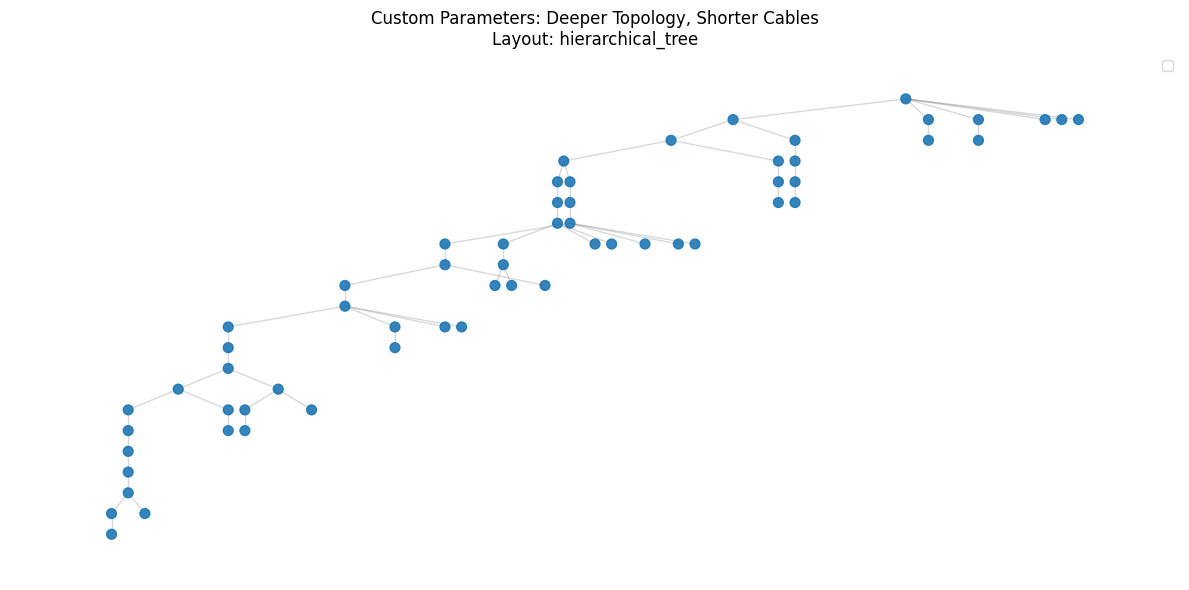

In [12]:
from powergrid_synth.distribution import NegBinomParams, ModifiedCauchyParams

# Create a feeder with deeper topology and shorter cables
custom = DistributionSynthParams(
    hop_dist=NegBinomParams(r=5.0, p=0.3),            # more hops
    cable_length=ModifiedCauchyParams(x0=0.05, gamma=0.08),  # shorter cables
)
gen_custom = SchweetzerFeederGenerator(params=custom, seed=77)
G_custom = DistributionGrid.from_nx(
    gen_custom.generate_feeder(n_nodes=60, total_load_mw=10.0, total_gen_mw=2.0)
)

print(f"Custom feeder: {G_custom.number_of_nodes()} nodes")
print(f"  Root: {G_custom.root}, Max hop: {G_custom.max_hop}, Is radial: {G_custom.is_radial}")
print(f"  Load: {G_custom.total_load_mw:.2f} MW, Gen: {G_custom.total_gen_mw:.2f} MW")

viz.plot_grid(
    G_custom,
    layout="hierarchical_tree",
    title="Custom Parameters: Deeper Topology, Shorter Cables",
    figsize=(12, 6),
)